In [11]:
import pandas as pd

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# print((df['stroke']==1).sum())
print(X.info())
# print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 399.3 KB
None


In [12]:
# Splits data into 80/20 ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# MedianImputerTransformer(replace N/A with median)
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class MedianImputerTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns):
        self.columns = columns
        self.learned_median = {}
        
        
    def fit(self, X, y=None):
        
        for col in self.columns:
            self.learned_median[col] = X[col].median()
            
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        
        for col in self.columns:
            X_copy[col] = X_copy[col].fillna(self.learned_median[col])
            
        return X_copy
    
    def get_feature_names_out(self, input_features=None):
        
        return np.array(self.columns)

In [14]:
# Model's pipeline && preprocessor
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder

print(X.info())

#* Replaced N/A with median
#* Categorical -> Numerical values
preprocess = ColumnTransformer(
    transformers=[
        ('median_imputer', MedianImputerTransformer(columns=['bmi']), ['bmi']),
        ('encoder', OneHotEncoder(handle_unknown='ignore'), ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 399.3 KB
None


In [15]:
# Best settings for DecisionTree
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__class_weight' : ['balanced', None],
    'model__max_depth' : [3, 5, 7, 10, None],
    'model__min_samples_split' : [2, 5, 10, 20],
    'model__min_samples_leaf' : [1, 2, 4, 8],
    'model__criterion' : ['gini', 'entropy']
}


grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [16]:
# Train Model
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', None], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20

In [17]:
# Predictions

predictions = grid_search.predict(X_test)
print(predictions)

[1 0 0 ... 0 0 1]


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification Report(Precision, Recall, F-1 Score, and Overall Accuracy)
print(classification_report(y_test, predictions))

# Confusion Matrix
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

           0       0.99      0.64      0.78       972
           1       0.11      0.84      0.19        50

    accuracy                           0.65      1022
   macro avg       0.55      0.74      0.49      1022
weighted avg       0.94      0.65      0.75      1022



Confusion Matrix
[[625 347]
 [  8  42]]


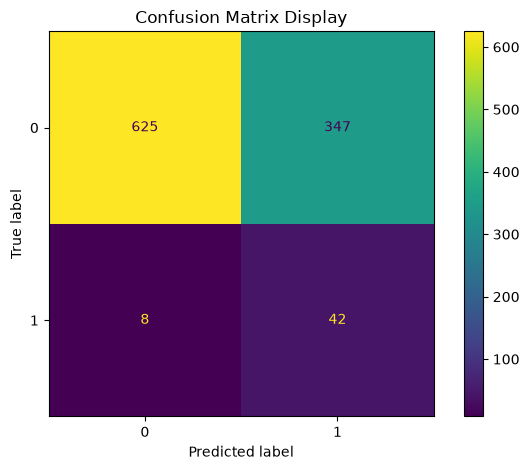

In [19]:
# Visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Confusion Matrix Display")

plt.tight_layout()


[Text(0.5, 0.875, 'remainder__age <= 47.5\ngini = 0.5\nsamples = 4088\nvalue = [2044.0, 2044.0]\nclass = Stroke'),
 Text(0.25, 0.625, 'remainder__age <= 37.5\ngini = 0.111\nsamples = 2191\nvalue = [1147.878, 71.899]\nclass = Healthy'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'remainder__age <= 1.36\ngini = 0.024\nsamples = 1601\nvalue = [840.936, 10.271]\nclass = Healthy'),
 Text(0.0625, 0.125, 'gini = 0.377\nsamples = 59\nvalue = [30.484, 10.271]\nclass = Healthy'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 1542\nvalue = [810.452, 0.0]\nclass = Healthy'),
 Text(0.375, 0.375, 'median_imputer__bmi <= 45.7\ngini = 0.279\nsamples = 590\nvalue = [306.942, 61.628]\nclass = Healthy'),
 Text(0.3125, 0.125, 'gini = 0.216\nsamples = 561\nvalue = [292.751, 41.085]\nclass = Healthy'),
 Text(0.4375, 0.125, 'gini = 0.483\nsamples = 29\nvalue = [14.191, 20.543]\nclass = Stroke'),
 Text(0.75, 0.625, 'remainder__age <= 67.5\ngini = 0.43\nsamples = 1897\nvalue = [896.122, 1972.101]\nclass =

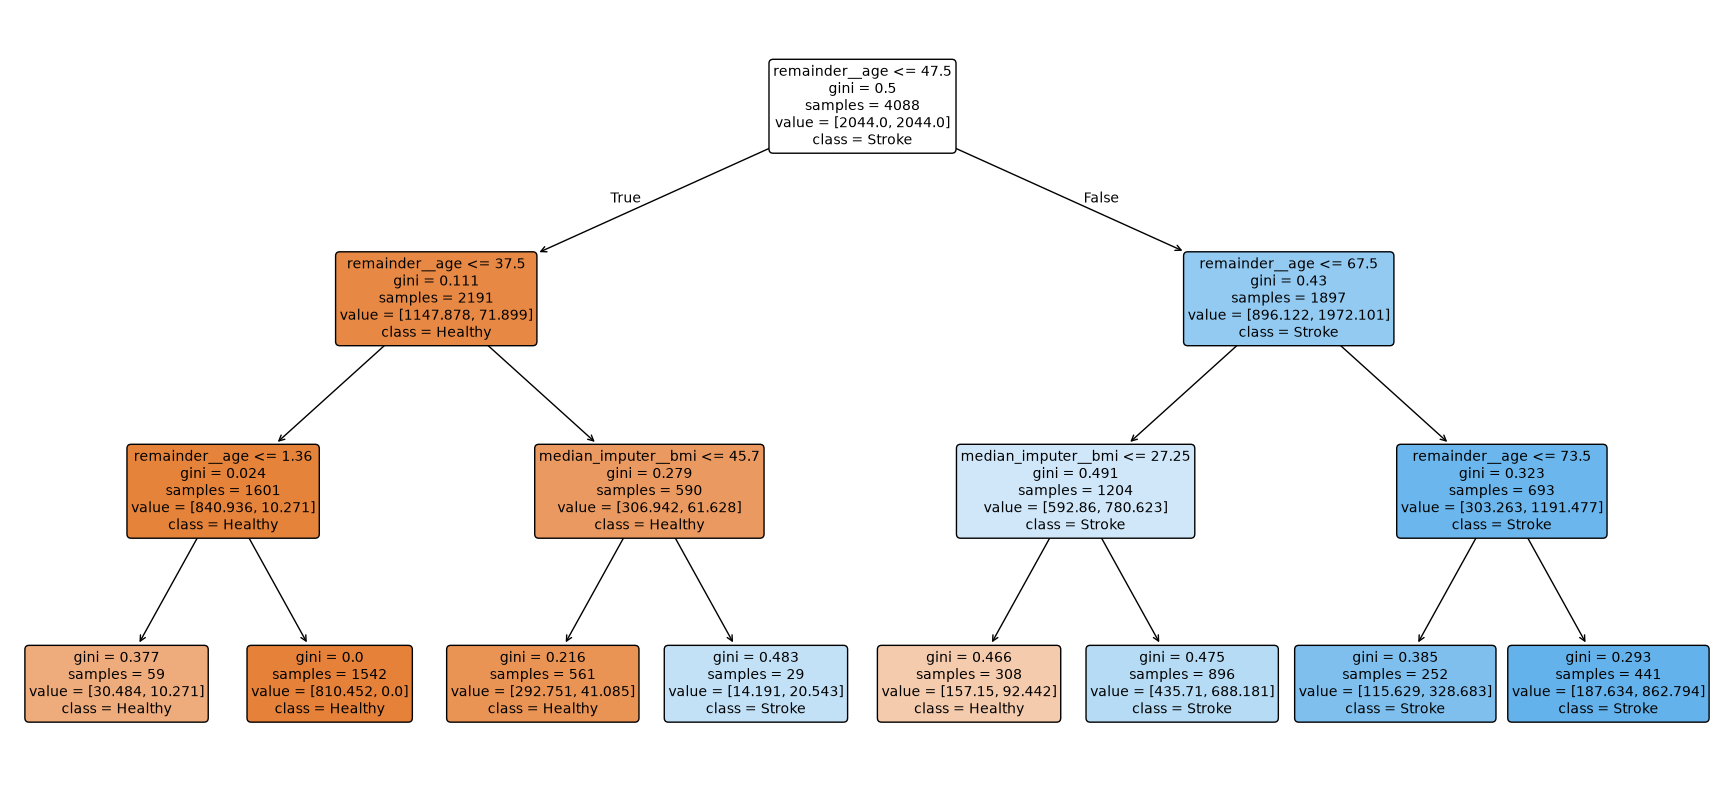

In [20]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 10))

best_estimator = grid_search.best_estimator_
preprocessor = best_estimator.named_steps['preprocess']

plot_tree(
    best_estimator.named_steps['model'],
    max_depth = 3,
    feature_names = preprocessor.get_feature_names_out(),
    class_names=['Healthy', 'Stroke'],
    filled=True, 
    rounded=True,
    fontsize=10,
    ax= ax
)